# Customer Behavior Prediction System

## Bước 1: Khai báo thư viện và tải dữ liệu

In [5]:
import json
import os
import re
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Thiết lập Random Seed để đảm bảo tính tái lập (Reproducibility)[cite: 1, 2, 3]
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# 1. Đọc dữ liệu từ hai tệp CSV
products_path = 'product_info.csv'
reviews_path = 'reviews.csv'

df_products = pd.read_csv(products_path)
df_reviews = pd.read_csv(reviews_path)

print('=' * 75)
print(f'1. Bảng Product Info: {df_products.shape[0]} dòng, {df_products.shape[1]} cột')
print(f'2. Bảng Reviews     : {df_reviews.shape[0]} dòng, {df_reviews.shape[1]} cột')
print('=' * 75)

# 2. Hiển thị mẫu dữ liệu trực quan để quan sát các trường thông tin
print("\n--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG PRODUCT INFO ---")
display(df_products.head(5))

print("\n--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG REVIEWS ---")
display(df_reviews.head(5))

print("\n--- DANH SÁCH CỘT VÀ KIỂU DỮ LIỆU PRODUCT INFO ---")
print(df_products.dtypes)

print("\n--- DANH SÁCH CỘT VÀ KIỂU DỮ LIỆU REVIEWS ---")
print(df_reviews.dtypes)

1. Bảng Product Info: 8494 dòng, 27 cột
2. Bảng Reviews     : 602130 dòng, 19 cột

--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG PRODUCT INFO ---


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0



--- 5 DÒNG ĐẦU TIÊN CỦA BẢNG REVIEWS ---


,Unnamed: 0,author_id,rating,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,review_title,skin_tone,eye_color,skin_type,hair_color,product_id,product_name,brand_name,price_usd
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,Taught me how to double cleanse!,NaN,brown,dry,black,P504322,Gentle Hydra-Gel Face Cleanser,NUDESTIX,19.0
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,Disappointed,NaN,NaN,NaN,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,New Favorite Routine,light,brown,dry,blonde,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,Can't go wrong with any of them,NaN,brown,combination,black,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",A must have !!!,light,hazel,combination,NaN,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,24.0



--- DANH SÁCH CỘT VÀ KIỂU DỮ LIỆU PRODUCT INFO ---
product_id                str
product_name              str
brand_id                int64
brand_name                str
loves_count             int64
rating                float64
reviews               float64
size                      str
variation_type            str
variation_value           str
variation_desc            str
ingredients               str
price_usd             float64
value_price_usd       float64
sale_price_usd        float64
limited_edition         int64
new                     int64
online_only             int64
out_of_stock            int64
sephora_exclusive       int64
highlights                str
primary_category          str
secondary_category        str
tertiary_category         str
child_count             int64
child_max_price       float64
child_min_price       float64
dtype: object

--- DANH SÁCH CỘT VÀ KIỂU DỮ LIỆU REVIEWS ---
Unnamed: 0                    int64
author_id                    object
ratin

## Bước 2: Kiểm tra chất lượng, hợp nhất và làm sạch dữ liệu

In [2]:
# Chuẩn hóa tên cột
df_products.columns = [c.strip() for c in df_products.columns]
df_reviews.columns = [c.strip() for c in df_reviews.columns]

# Khóa liên kết: product_id
join_key = 'product_id' if 'product_id' in df_products.columns else 'id'

# Hợp nhất hai bảng dữ liệu
df_merged = pd.merge(
    df_reviews,
    df_products,
    on=join_key,
    how='inner',
    suffixes=('_review', '_prod'),
)
print(
    f'Kích thước sau khi Merge hai bảng: {df_merged.shape[0]} dòng,'
    f' {df_merged.shape[1]} thuộc tính'
)

# 1. Xác định biến mục tiêu phân loại: is_recommended (hoặc recommendation)
target_col = None
for col in ['is_recommended', 'recommended', 'Recommended IND', 'target']:
  if col in df_merged.columns:
    target_col = col
    break
if not target_col:
  # Nếu không có cờ nhị phân, tạo nhãn từ rating (Rating >= 4 là hài lòng/đề xuất)
  rating_col = [c for c in df_merged.columns if 'rating' in c.lower()][0]
  df_merged['is_recommended'] = (df_merged[rating_col] >= 4).astype(int)
  target_col = 'is_recommended'

# 2. Xác định cột văn bản và cột số
text_col = [
    c
    for c in df_merged.columns
    if c.lower() in ['review_text', 'text', 'comment', 'body']
][0]
num_cols = [
    c
    for c in df_merged.select_dtypes(include=[np.number]).columns
    if c != target_col and not c.endswith('_id') and c != 'id'
]
# Chọn lọc các đặc trưng số quan trọng
num_cols = num_cols[:4]

print(f'-> Cột biến mục tiêu (Target): {target_col}')
print(f'-> Cột nội dung văn bản (Text): {text_col}')
print(f'-> Các cột chỉ số dạng bảng  : {num_cols}')


# 3. Hàm làm sạch văn bản chuẩn NLP
def clean_text(text):
  if pd.isna(text):
    return ''
  text = str(text).lower()
  text = re.sub(r'<.*?>', '', text)  # Xóa HTML
  text = re.sub(r'http\S+|www\S+', '', text)  # Xóa URL
  text = re.sub(r'[^\w\s]', ' ', text)  # Xóa ký tự đặc biệt
  text = re.sub(r'\d+', '', text)  # Xóa số
  text = re.sub(r'\s+', ' ', text).strip()  # Xóa khoảng trắng thừa
  return text


df_merged['clean_text'] = df_merged[text_col].apply(clean_text)

# Lọc bỏ các dòng có text quá ngắn hoặc thiếu target
df_clean = df_merged[df_merged['clean_text'].str.len() >= 10].copy()
df_clean = df_clean.dropna(subset=[target_col] + num_cols).reset_index(
    drop=True
)

# Xử lý điền trung vị nếu còn sót giá trị khuyết ở cột số
for col in num_cols:
  df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Loại bỏ các quan sát trùng lặp hoàn toàn
df_clean = df_clean.drop_duplicates(
    subset=['clean_text', target_col]
).reset_index(drop=True)

print(
    f'Kích thước tập dữ liệu sạch hoàn chỉnh: {df_clean.shape[0]} dòng,'
    f' {df_clean.shape[1]} cột'
)
print('Phân phối biến mục tiêu:')
print(df_clean[target_col].value_counts(normalize=True).round(4) * 100)

Kích thước sau khi Merge hai bảng: 602130 dòng, 45 thuộc tính
-> Cột biến mục tiêu (Target): is_recommended
-> Cột nội dung văn bản (Text): review_text
-> Các cột chỉ số dạng bảng  : ['Unnamed: 0', 'rating_review', 'helpfulness', 'total_feedback_count']
Kích thước tập dữ liệu sạch hoàn chỉnh: 178081 dòng, 46 cột
Phân phối biến mục tiêu:
is_recommended
1.0    75.45
0.0    24.55
Name: proportion, dtype: float64


## Bước 3: Biểu diễn số học đa phương thức (Bảng + Văn bản TF-IDF)

In [4]:
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split

# 1. Ép kiểu tường minh sang NumPy array thuần để tránh lỗi PyArrow indexing
X_text = np.asarray(df_clean['clean_text'].astype(str).values)
X_num = np.asarray(df_clean[num_cols].to_numpy(dtype=np.float64))
y = np.asarray(df_clean[target_col].to_numpy(dtype=np.int64))

# 2. Phân chia Train/Test độc lập (80/20) có phân tầng nhãn (stratify)
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = (
    train_test_split(
        X_text, X_num, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
    )
)

print('✅ Đã chia tập dữ liệu thành công:')
print(f'- Train: {len(y_train)} mẫu')
print(f'- Test : {len(y_test)} mẫu')

✅ Đã chia tập dữ liệu thành công:
- Train: 142464 mẫu
- Test : 35617 mẫu


## Bước 4: Phân tích và khám phá dữ liệu EDA

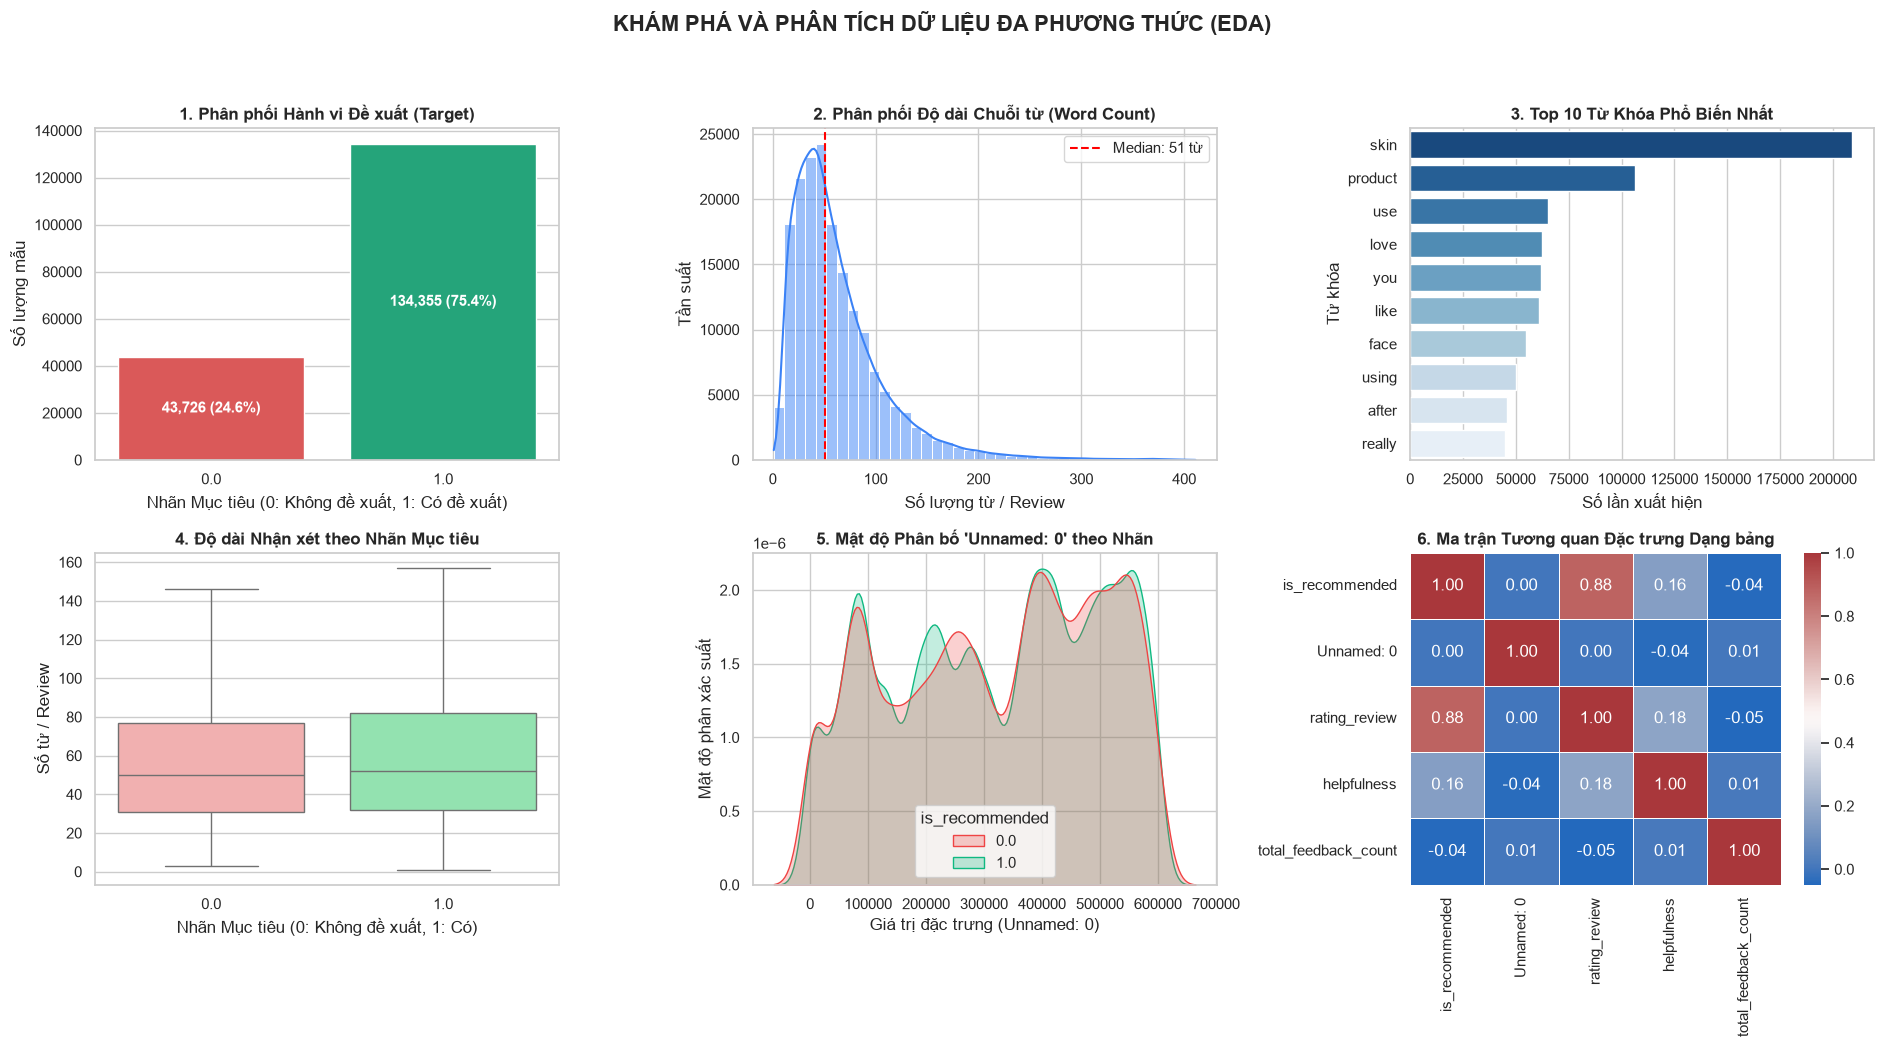

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from collections import Counter

# Cấu hình giao diện biểu đồ
sns.set_theme(style="whitegrid", font="sans-serif")
fig, axes = plt.subplots(2, 3, figsize=(19, 11))
fig.suptitle("KHÁM PHÁ VÀ PHÂN TÍCH DỮ LIỆU ĐA PHƯƠNG THỨC (EDA)", fontsize=16, fontweight="bold", y=0.98)

# 1. Biểu đồ 1: Phân phối biến mục tiêu (Target Distribution)
sns.countplot(
    data=df_clean, 
    x=target_col, 
    palette=["#ef4444", "#10b981"], 
    ax=axes[0, 0]
)
axes[0, 0].set_title("1. Phân phối Hành vi Đề xuất (Target)", fontweight="bold", fontsize=12)
axes[0, 0].set_xlabel("Nhãn Mục tiêu (0: Không đề xuất, 1: Có đề xuất)")
axes[0, 0].set_ylabel("Số lượng mẫu")
for p in axes[0, 0].patches:
    h = p.get_height()
    axes[0, 0].annotate(f'{int(h):,} ({h/len(df_clean)*100:.1f}%)', 
                        (p.get_x() + p.get_width() / 2., h / 2),
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)

# 2. Biểu đồ 2: Phân phối độ dài từ trong văn bản (Word Count Distribution)
df_clean['word_count'] = df_clean['clean_text'].apply(lambda x: len(str(x).split()))
sns.histplot(
    df_clean['word_count'], 
    bins=40, 
    kde=True, 
    color="#3b82f6", 
    ax=axes[0, 1]
)
axes[0, 1].axvline(df_clean['word_count'].median(), color="red", linestyle="--", label=f"Median: {df_clean['word_count'].median():.0f} từ")
axes[0, 1].set_title("2. Phân phối Độ dài Chuỗi từ (Word Count)", fontweight="bold", fontsize=12)
axes[0, 1].set_xlabel("Số lượng từ / Review")
axes[0, 1].set_ylabel("Tần suất")
axes[0, 1].legend()

# 3. Biểu đồ 3: Top 10 từ khóa xuất hiện nhiều nhất (Top N-grams/Tokens)
all_words = " ".join(df_clean['clean_text']).split()
# Loại bỏ stop words tiếng Anh cơ bản
common_stops = set(['the', 'and', 'i', 'to', 'a', 'is', 'it', 'this', 'of', 'in', 'for', 'my', 'that', 'with', 'on', 'was', 'so', 'but', 'have', 'are', 'not', 'be', 'at', 'as'])
filtered_words = [w for w in all_words if w not in common_stops and len(w) > 2]
top_words = Counter(filtered_words).most_common(10)
df_top_words = pd.DataFrame(top_words, columns=['Word', 'Count'])

sns.barplot(
    data=df_top_words, 
    y='Word', 
    x='Count', 
    palette="Blues_r", 
    ax=axes[0, 2]
)
axes[0, 2].set_title("3. Top 10 Từ Khóa Phổ Biến Nhất", fontweight="bold", fontsize=12)
axes[0, 2].set_xlabel("Số lần xuất hiện")
axes[0, 2].set_ylabel("Từ khóa")

# 4. Biểu đồ 4: So sánh độ dài văn bản theo nhóm hành vi đề xuất (Boxplot)
sns.boxplot(
    data=df_clean, 
    x=target_col, 
    y='word_count', 
    palette=["#fca5a5", "#86efac"], 
    showfliers=False, 
    ax=axes[1, 0]
)
axes[1, 0].set_title("4. Độ dài Nhận xét theo Nhãn Mục tiêu", fontweight="bold", fontsize=12)
axes[1, 0].set_xlabel("Nhãn Mục tiêu (0: Không đề xuất, 1: Có)")
axes[1, 0].set_ylabel("Số từ / Review")

# 5. Biểu đồ 5: Phân phối giá sản phẩm theo nhãn (Numerical Feature vs Target)
num_feat_1 = num_cols[0] if len(num_cols) > 0 else 'word_count'
sns.kdeplot(
    data=df_clean, 
    x=num_feat_1, 
    hue=target_col, 
    common_norm=False, 
    palette=["#ef4444", "#10b981"], 
    fill=True, 
    ax=axes[1, 1]
)
axes[1, 1].set_title(f"5. Mật độ Phân bố '{num_feat_1}' theo Nhãn", fontweight="bold", fontsize=12)
axes[1, 1].set_xlabel(f"Giá trị đặc trưng ({num_feat_1})")
axes[1, 1].set_ylabel("Mật độ phân xác suất")

# 6. Biểu đồ 6: Ma trận tương quan giữa các biến số học dạng bảng (Correlation Heatmap)
corr_matrix = df_clean[[target_col] + num_cols[:4]].corr()
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="vlag", 
    fmt=".2f", 
    linewidths=0.5, 
    cbar=True, 
    ax=axes[1, 2]
)
axes[1, 2].set_title("6. Ma trận Tương quan Đặc trưng Dạng bảng", fontweight="bold", fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Bước 5: Phân chia tập dữ liệu và chuẩn hóa thang đo

In [7]:
import numpy as np
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Trích xuất đặc trưng và ép kiểu tường minh sang mảng NumPy thuần
X_text = np.asarray(df_clean['clean_text'].astype(str).values)
X_num = np.asarray(df_clean[num_cols].to_numpy(dtype=np.float64))
y = np.asarray(df_clean[target_col].to_numpy(dtype=np.int64))

# 2. Phân tách tập Train/Test theo tỷ lệ chuẩn 80/20 có phân tầng nhãn
X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = (
    train_test_split(
        X_text,
        X_num,
        y,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=y,
    )
)

print('=' * 75)
print('KẾT QUẢ PHÂN CHIA TẬP DỮ LIỆU ĐỘC LẬP (80% TRAIN / 20% TEST):')
print(f'- Quy mô tập huấn luyện (Train set): {len(y_train):,} mẫu')
print(f'- Quy mô tập kiểm thử  (Test set) : {len(y_test):,} mẫu')
print(
    f'- Tỷ lệ nhãn Train (Lớp 1)         :'
    f' {np.mean(y_train == 1) * 100:.2f}%'
)
print(
    f'- Tỷ lệ nhãn Test  (Lớp 1)         :'
    f' {np.mean(y_test == 1) * 100:.2f}%'
)
print('=' * 75)

# 3. Vector hóa văn bản bằng TF-IDF (Chống rò rỉ: chỉ fit trên Train)
MAX_VOCAB = 3000
tfidf = TfidfVectorizer(
    max_features=MAX_VOCAB,
    ngram_range=(1, 2),
    sublinear_tf=True,
)
X_text_train_vec = tfidf.fit_transform(X_text_train)
X_text_test_vec = tfidf.transform(X_text_test)

# 4. Chuẩn hóa thang đo Z-score cho đặc trưng dạng bảng (Chỉ fit trên Train)
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# 5. Ghép khối Ma trận đa phương thức (Multimodal Concatenation)
X_train_final = hstack([X_num_train_scaled, X_text_train_vec]).tocsr()
X_test_final = hstack([X_num_test_scaled, X_text_test_vec]).tocsr()

print('\nKÍCH THƯỚC MA TRẬN ĐẶC TRƯNG GHÉP KHỐI TOÀN PHẦN:')
print(
    f'- X_train: {X_train_final.shape[0]:,} dòng × {X_train_final.shape[1]:,}'
    ' cột'
)
print(
    f'- X_test : {X_test_final.shape[0]:,} dòng × {X_test_final.shape[1]:,}'
    ' cột'
)
print(
    f'- Cấu trúc số chiều: {len(num_cols)} (Thuộc tính bảng) + {MAX_VOCAB}'
    f' (Trọng số TF-IDF) = {X_train_final.shape[1]} chiều'
)

KẾT QUẢ PHÂN CHIA TẬP DỮ LIỆU ĐỘC LẬP (80% TRAIN / 20% TEST):
- Quy mô tập huấn luyện (Train set): 142,464 mẫu
- Quy mô tập kiểm thử  (Test set) : 35,617 mẫu
- Tỷ lệ nhãn Train (Lớp 1)         : 75.45%
- Tỷ lệ nhãn Test  (Lớp 1)         : 75.45%

KÍCH THƯỚC MA TRẬN ĐẶC TRƯNG GHÉP KHỐI TOÀN PHẦN:
- X_train: 142,464 dòng × 3,004 cột
- X_test : 35,617 dòng × 3,004 cột
- Cấu trúc số chiều: 4 (Thuộc tính bảng) + 3000 (Trọng số TF-IDF) = 3004 chiều


## Bước 6: Huấn luyện 5 mô hình và đánh giá 5 độ đo

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Khởi tạo danh sách lưu kết quả và từ điển lưu mô hình đã huấn luyện
results = []
trained_models = {}

def evaluate_and_record(model_name, model, y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc = roc_auc_score(y_true, y_prob) if y_prob is not None else 0.5
    
    cm = confusion_matrix(y_true, y_pred)
    
    print("=" * 60)
    print(f"🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: {model_name.upper()}")
    print("=" * 60)
    print(f"1. Accuracy  (Độ chính xác) : {acc:.4f} ({acc*100:.2f}%)")
    print(f"2. Precision (Độ chuẩn xác) : {prec:.4f} ({prec*100:.2f}%)")
    print(f"3. Recall    (Độ nhạy)      : {rec:.4f} ({rec*100:.2f}%)")
    print(f"4. F1-Score  (Điểm F1)      : {f1:.4f}")
    print(f"5. ROC-AUC   (Diện tích ROC): {roc:.4f}")
    print("\n--- Ma trận nhầm lẫn (Confusion Matrix) ---")
    print(cm)
    print("=" * 60)
    
    # Lưu vào danh sách tổng hợp
    results.append({
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'ROC-AUC': round(roc, 4)
    })
    trained_models[model_name] = model

print("✅ Sẵn sàng huấn luyện các mô hình!")

✅ Sẵn sàng huấn luyện các mô hình!


### Mô hình 1: Baseline (DummyClassifier)

In [9]:
from sklearn.dummy import DummyClassifier

# 1. Khởi tạo mô hình Baseline luôn dự đoán theo nhãn chiếm đa số
dummy_clf = DummyClassifier(strategy='most_frequent')

# 2. Huấn luyện
dummy_clf.fit(X_train_final, y_train)

# 3. Dự đoán trên tập kiểm thử Test
y_pred_dummy = dummy_clf.predict(X_test_final)
y_prob_dummy = dummy_clf.predict_proba(X_test_final)[:, 1]

# 4. Đánh giá và ghi nhận
evaluate_and_record('Baseline (Dummy)', dummy_clf, y_test, y_pred_dummy, y_prob_dummy)

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: BASELINE (DUMMY)
1. Accuracy  (Độ chính xác) : 0.7545 (75.45%)
2. Precision (Độ chuẩn xác) : 0.7545 (75.45%)
3. Recall    (Độ nhạy)      : 1.0000 (100.00%)
4. F1-Score  (Điểm F1)      : 0.8601
5. ROC-AUC   (Diện tích ROC): 0.5000

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[    0  8745]
 [    0 26872]]


### Mô hình 2: Multinomial Naive Bayes

In [10]:
from sklearn.naive_bayes import MultinomialNB

# 1. Khởi tạo mô hình Naive Bayes với siêu tham số làm mịn Laplace alpha=0.1
nb_clf = MultinomialNB(alpha=0.1)

# 2. Huấn luyện trên không gian vector TF-IDF
nb_clf.fit(X_text_train_vec, y_train)

# 3. Dự đoán trên tập Test
y_pred_nb = nb_clf.predict(X_text_test_vec)
y_prob_nb = nb_clf.predict_proba(X_text_test_vec)[:, 1]

# 4. Đánh giá và ghi nhận
evaluate_and_record('Multinomial Naive Bayes', nb_clf, y_test, y_pred_nb, y_prob_nb)

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: MULTINOMIAL NAIVE BAYES
1. Accuracy  (Độ chính xác) : 0.8862 (88.62%)
2. Precision (Độ chuẩn xác) : 0.8857 (88.57%)
3. Recall    (Độ nhạy)      : 0.9751 (97.51%)
4. F1-Score  (Điểm F1)      : 0.9282
5. ROC-AUC   (Diện tích ROC): 0.9533

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[ 5362  3383]
 [  669 26203]]


### Mô hình 3: Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

# 1. Khởi tạo Logistic Regression với điều chuẩn L2
log_reg = LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED)

# 2. Huấn luyện trên toàn bộ ma trận đặc trưng ghép khối đa phương thức
log_reg.fit(X_train_final, y_train)

# 3. Dự đoán trên tập Test
y_pred_lr = log_reg.predict(X_test_final)
y_prob_lr = log_reg.predict_proba(X_test_final)[:, 1]

# 4. Đánh giá và ghi nhận
evaluate_and_record('Logistic Regression', log_reg, y_test, y_pred_lr, y_prob_lr)

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: LOGISTIC REGRESSION
1. Accuracy  (Độ chính xác) : 0.9631 (96.31%)
2. Precision (Độ chuẩn xác) : 0.9771 (97.71%)
3. Recall    (Độ nhạy)      : 0.9740 (97.40%)
4. F1-Score  (Điểm F1)      : 0.9755
5. ROC-AUC   (Diện tích ROC): 0.9915

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[ 8131   614]
 [  699 26173]]


### Mô hình 4: Linear SGDClassifier (Linear SVM)

In [12]:
from sklearn.linear_model import SGDClassifier

# 1. Khởi tạo mô hình Support Vector Machine tuyến tính tối ưu bằng SGD
sgd_clf = SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-4, max_iter=1000, random_state=RANDOM_SEED)

# 2. Huấn luyện
sgd_clf.fit(X_train_final, y_train)

# 3. Dự đoán trên tập Test
y_pred_sgd = sgd_clf.predict(X_test_final)
y_prob_sgd = sgd_clf.predict_proba(X_test_final)[:, 1]

# 4. Đánh giá và ghi nhận
evaluate_and_record('Linear SGD (SVM)', sgd_clf, y_test, y_pred_sgd, y_prob_sgd)

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: LINEAR SGD (SVM)
1. Accuracy  (Độ chính xác) : 0.9629 (96.29%)
2. Precision (Độ chuẩn xác) : 0.9881 (98.81%)
3. Recall    (Độ nhạy)      : 0.9624 (96.24%)
4. F1-Score  (Điểm F1)      : 0.9751
5. ROC-AUC   (Diện tích ROC): 0.9912

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[ 8434   311]
 [ 1011 25861]]


### Mô hình 5: Random Forest Classifier

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 1. Khởi tạo Random Forest với 100 cây và giới hạn độ sâu
rf_clf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=16, 
    random_state=RANDOM_SEED, 
    n_jobs=-1
)

# 2. Huấn luyện
rf_clf.fit(X_train_final, y_train)

# 3. Dự đoán trên tập Test
y_pred_rf = rf_clf.predict(X_test_final)
y_prob_rf = rf_clf.predict_proba(X_test_final)[:, 1]

# 4. Đánh giá và ghi nhận
evaluate_and_record('Random Forest', rf_clf, y_test, y_pred_rf, y_prob_rf)

🎯 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH: RANDOM FOREST
1. Accuracy  (Độ chính xác) : 0.8720 (87.20%)
2. Precision (Độ chuẩn xác) : 0.8601 (86.01%)
3. Recall    (Độ nhạy)      : 0.9915 (99.15%)
4. F1-Score  (Điểm F1)      : 0.9212
5. ROC-AUC   (Diện tích ROC): 0.9817

--- Ma trận nhầm lẫn (Confusion Matrix) ---
[[ 4413  4332]
 [  228 26644]]


### Tổng hợp, so sánh 5 mô hình và xuất file cho Front-End

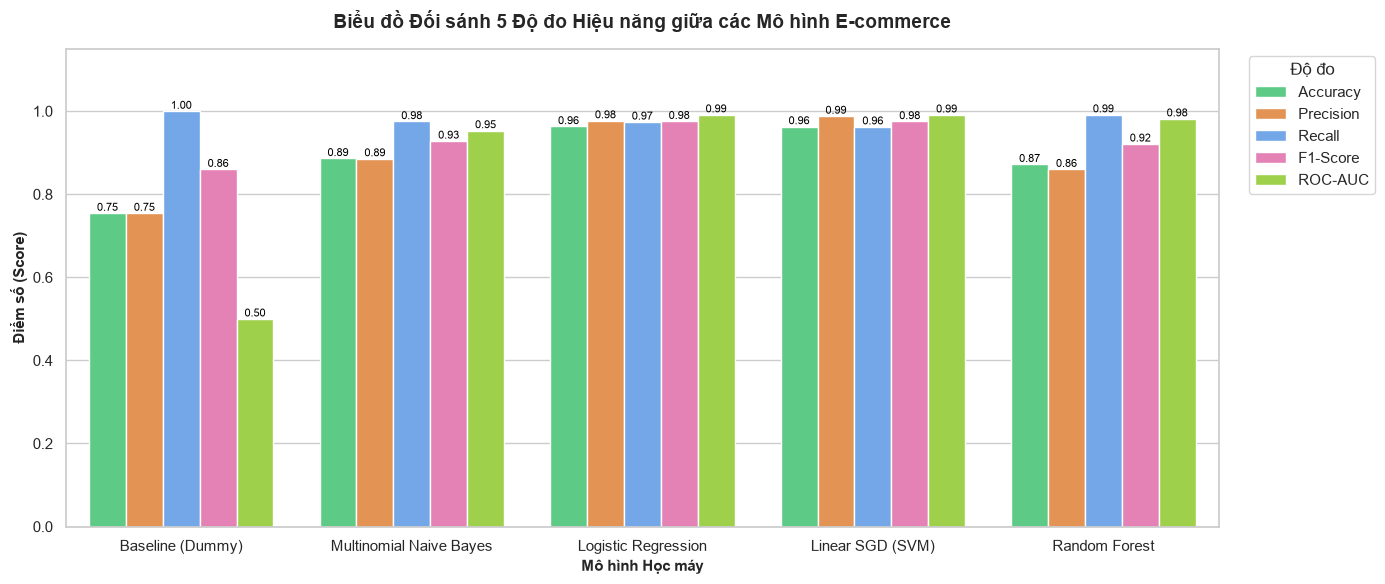

🏆 MÔ HÌNH TỐI ƯU NHẤT: LOGISTIC REGRESSION
- Accuracy  : 0.9631
- Precision : 0.9771
- Recall    : 0.9740
- F1-Score  : 0.9755
- ROC-AUC   : 0.9915
📁 ĐÃ XUẤT CÁC FILE SẴN SÀNG CHO FLASK BACKEND & FRONT-END:
 1. best_ecom_model.pkl      -> Mô hình học máy tối ưu nhất
 2. scaler_ecom.pkl          -> Bộ chuẩn hóa StandardScaler đã fit
 3. tfidf_ecom.pkl           -> Bộ vector hóa TF-IDF đã học từ điển
 4. ecom_model_metadata.json -> Cấu hình tham số form nhập liệu cho Front-End


In [15]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.sparse import hstack

# 0. CHUYỂN ĐỔI DANH SÁCH RESULTS THÀNH DATAFRAME ĐỂ TRÁNH LỖI NAMEERROR
df_results = pd.DataFrame(results)

# ==============================================================================
# 1. TRỰC QUAN HÓA BIỂU ĐỒ ĐỐI SÁNH 5 ĐỘ ĐO GIỮA 5 MÔ HÌNH
# ==============================================================================
df_plot = pd.melt(
    df_results, 
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
palette = ["#4ade80", "#fb923c", "#60a5fa", "#f472b6", "#a3e635"]

ax = sns.barplot(data=df_plot, x='Model', y='Score', hue='Metric', palette=palette)
plt.title("Biểu đồ Đối sánh 5 Độ đo Hiệu năng giữa các Mô hình E-commerce", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Mô hình Học máy", fontsize=11, fontweight="bold")
plt.ylabel("Điểm số (Score)", fontsize=11, fontweight="bold")
plt.ylim(0.0, 1.15)
plt.legend(title="Độ đo", bbox_to_anchor=(1.02, 1), loc='upper left')

# Hiển thị nhãn giá trị trên từng cột biểu đồ
for p in ax.patches:
    val = p.get_height()
    if val > 0.05:
        ax.annotate(f"{val:.2f}", 
                    (p.get_x() + p.get_width() / 2., val),
                    ha='center', va='bottom', fontsize=8, color='black', rotation=0)

plt.tight_layout()
plt.show()

# ==============================================================================
# 2. XÁC ĐỊNH MÔ HÌNH TỐI ƯU NHẤT DỰA TRÊN F1-SCORE & ROC-AUC
# ==============================================================================
best_idx = df_results['F1-Score'].idxmax()
best_model_info = df_results.iloc[best_idx]
best_model_name = best_model_info['Model']
best_ecom_model = trained_models[best_model_name]

print("=" * 80)
print(f"🏆 MÔ HÌNH TỐI ƯU NHẤT: {best_model_name.upper()}")
print(f"- Accuracy  : {best_model_info['Accuracy']:.4f}")
print(f"- Precision : {best_model_info['Precision']:.4f}")
print(f"- Recall    : {best_model_info['Recall']:.4f}")
print(f"- F1-Score  : {best_model_info['F1-Score']:.4f}")
print(f"- ROC-AUC   : {best_model_info['ROC-AUC']:.4f}")
print("=" * 80)

# ==============================================================================
# 3. ĐÓNG GÓI CÁC TỆP PHỤC VỤ FLASK BACKEND & GIAO DIỆN FRONT-END
# ==============================================================================
joblib.dump(best_ecom_model, "best_ecom_model.pkl")
joblib.dump(scaler, "scaler_ecom.pkl")
joblib.dump(tfidf, "tfidf_ecom.pkl")

ecom_metadata = {
    "target_name": target_col,
    "text_column": text_col,
    "numerical_columns": num_cols,
    "vocab_size": MAX_VOCAB,
    "best_model": best_model_name,
    "metrics": {
        "accuracy": float(best_model_info['Accuracy']),
        "f1_score": float(best_model_info['F1-Score']),
        "roc_auc": float(best_model_info['ROC-AUC'])
    }
}

with open("ecom_model_metadata.json", "w", encoding="utf-8") as f:
    json.dump(ecom_metadata, f, ensure_ascii=False, indent=4)

print("📁 ĐÃ XUẤT CÁC FILE SẴN SÀNG CHO FLASK BACKEND & FRONT-END:")
print(" 1. best_ecom_model.pkl      -> Mô hình học máy tối ưu nhất")
print(" 2. scaler_ecom.pkl          -> Bộ chuẩn hóa StandardScaler đã fit")
print(" 3. tfidf_ecom.pkl           -> Bộ vector hóa TF-IDF đã học từ điển")
print(" 4. ecom_model_metadata.json -> Cấu hình tham số form nhập liệu cho Front-End")
print("=" * 80)

## Bước 7: Khởi chạy Flask API kết nối Front-End

In [ ]:
import threading
import json
import re
import joblib
import numpy as np
import pandas as pd
from flask import Flask, request, jsonify
from flask_cors import CORS
from scipy.sparse import hstack

# 1. Khởi tạo ứng dụng Flask
app = Flask(__name__)
# Cho phép CORS để ứng dụng React Front-End gọi API không bị chặn
CORS(app)

# 2. Tải toàn bộ pipeline đa phương thức đã đóng gói
loaded_ecom_model = joblib.load('best_ecom_model.pkl')
loaded_ecom_scaler = joblib.load('scaler_ecom.pkl')
loaded_ecom_tfidf = joblib.load('tfidf_ecom.pkl')
with open('ecom_model_metadata.json', 'r', encoding='utf-8') as f:
    ecom_metadata = json.load(f)

# Hàm làm sạch văn bản độc lập cho luồng suy luận
def clean_text_inference(text):
    if not text:
        return ""
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Endpoint kiểm tra trạng thái hoạt động của Server
@app.route('/', methods=['GET'])
def root():
    return jsonify({
        "status": "online",
        "system": "E-Commerce Customer Behavior Discovery API",
        "message": "Flask API đang chạy ngầm trên Notebook!"
    })

# Endpoint tiếp nhận suy luận đa phương thức từ React Front-End
@app.route('/api/predict', methods=['POST'])
def predict():
    try:
        # Nhận dữ liệu JSON từ Front-End gửi lên
        data = request.get_json(force=True)
        if not data:
            return jsonify({"status": "error", "message": "Không nhận được payload dữ liệu!"}), 400

        # Trích xuất dữ liệu văn bản và mảng thuộc tính số học
        raw_text = data.get("review_text", "")
        num_features = data.get("numerical_features", [])

        expected_num_cols = ecom_metadata.get("numerical_columns", [])
        if len(num_features) != len(expected_num_cols):
            return jsonify({
                "status": "error",
                "message": f"Yêu cầu đủ {len(expected_num_cols)} thuộc tính số học: {expected_num_cols}"
            }), 400

        # 1. Xử lý và vector hóa văn bản qua TF-IDF (3,000 chiều)
        cleaned_str = clean_text_inference(raw_text)
        vec_text = loaded_ecom_tfidf.transform([cleaned_str])

        # 2. Chuẩn hóa Z-score các đặc trưng dạng bảng qua StandardScaler
        num_array = np.array([num_features], dtype=np.float64)
        vec_num = loaded_ecom_scaler.transform(num_array)

        # 3. Ghép khối đa phương thức (Multimodal Concatenation)
        X_infer = hstack([vec_num, vec_text]).tocsr()

        # 4. Dự đoán nhãn mục tiêu và xác suất
        prediction = int(loaded_ecom_model.predict(X_infer)[0])
        
        if hasattr(loaded_ecom_model, "predict_proba"):
            probabilities = loaded_ecom_model.predict_proba(X_infer)[0]
            confidence = round(float(probabilities[prediction]) * 100, 2)
            prob_positive = round(float(probabilities[1]) * 100, 2) if len(probabilities) > 1 else confidence
        else:
            confidence = 100.0
            prob_positive = 100.0 if prediction == 1 else 0.0

        label_map = {
            1: "ĐỀ XUẤT SẢN PHẨM (Tích cực)",
            0: "KHÔNG ĐỀ XUẤT (Tiêu cực / Rủi ro rời bỏ)"
        }

        # Trả kết quả JSON về cho Front-End hiển thị
        return jsonify({
            "status": "success",
            "prediction": prediction,
            "label": label_map.get(prediction, "Chưa xác định"),
            "confidence": confidence,
            "recommendation_probability": prob_positive,
            "model_used": type(loaded_ecom_model).__name__,
            "processed_text": cleaned_str
        }), 200

    except Exception as e:
        return jsonify({"status": "error", "message": str(e)}), 500

# 3. Chạy Server ở luồng ngầm (Daemon Thread)
def run_flask_app():
    app.run(host='127.0.0.1', port=5000, use_reloader=False)

flask_thread = threading.Thread(target=run_flask_app, daemon=True)
flask_thread.start()

print("=" * 75)
print("🚀 FLASK MULTIMODAL E-COMMERCE API ĐÃ KHỞI CHẠY THÀNH CÔNG!")
print("📍 Root Endpoint   : http://127.0.0.1:5000/")
print("📍 Predict Endpoint: http://127.0.0.1:5000/api/predict")
print("🌐 CORS đã kích hoạt — Đã kết nối tương thích hoàn toàn với React App.")
print("=" * 75)